In [21]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
# Install Required Libraries
%pip install xgboost catboost


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
# Cell 2: Load Network Train/Test Files
X_train_net = pd.read_csv("X_train.csv")
X_test_net = pd.read_csv("X_test.csv")
y_train_net = pd.read_csv("y_train.csv")
y_test_net = pd.read_csv("y_test.csv")

print("X_train:", X_train_net.shape)
print("X_test:", X_test_net.shape)
print("y_train:", y_train_net.shape)
print("y_test:", y_test_net.shape)

X_train: (683955, 39)
X_test: (170989, 39)
y_train: (683955, 1)
y_test: (170989, 1)


In [23]:
# Cell 3: Prepare Labels
if "label" in y_train_net.columns:
    y_train_net = y_train_net["label"]
    y_test_net = y_test_net["label"]
else:
    y_train_net = y_train_net.iloc[:, 0]
    y_test_net = y_test_net.iloc[:, 0]

print(y_train_net.value_counts())

label
0    625711
1     58244
Name: count, dtype: int64


In [24]:
# Cell 4: Train Network Random Forest Baseline
rf_network = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_network.fit(X_train_net, y_train_net)
rf_net_pred = rf_network.predict(X_test_net)

print("Network RF Accuracy:", accuracy_score(y_test_net, rf_net_pred))
print(classification_report(y_test_net, rf_net_pred))

Network RF Accuracy: 0.9675242267046418
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    156428
           1       0.72      1.00      0.84     14561

    accuracy                           0.97    170989
   macro avg       0.86      0.98      0.91    170989
weighted avg       0.98      0.97      0.97    170989



In [25]:
# Cell 5: Train Network XGBoost Baseline
from xgboost import XGBClassifier

xgb_network = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_network.fit(X_train_net, y_train_net)
xgb_net_pred = xgb_network.predict(X_test_net)

print("Network XGB Accuracy:", accuracy_score(y_test_net, xgb_net_pred))
print(classification_report(y_test_net, xgb_net_pred))

Network XGB Accuracy: 0.9996257069168192
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    156428
           1       1.00      1.00      1.00     14561

    accuracy                           1.00    170989
   macro avg       1.00      1.00      1.00    170989
weighted avg       1.00      1.00      1.00    170989



In [26]:
# Cell 6: Train Network CatBoost Baseline
from catboost import CatBoostClassifier

cat_network = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

cat_network.fit(X_train_net, y_train_net)
cat_net_pred = cat_network.predict(X_test_net)

print("Network CatBoost Accuracy:", accuracy_score(y_test_net, cat_net_pred))
print(classification_report(y_test_net, cat_net_pred))

Network CatBoost Accuracy: 0.9996549485639427
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    156428
           1       1.00      1.00      1.00     14561

    accuracy                           1.00    170989
   macro avg       1.00      1.00      1.00    170989
weighted avg       1.00      1.00      1.00    170989



In [27]:
# Cell 7: Train Network Logistic Regression Baseline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale data for LR
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_net)
X_test_lr = scaler.transform(X_test_net)

lr_network = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

lr_network.fit(X_train_lr, y_train_net)
lr_net_pred = lr_network.predict(X_test_lr)

print("Network LR Accuracy:", accuracy_score(y_test_net, lr_net_pred))
print(classification_report(y_test_net, lr_net_pred))

Network LR Accuracy: 0.6870032575194895
              precision    recall  f1-score   support

           0       1.00      0.66      0.79    156428
           1       0.21      0.99      0.35     14561

    accuracy                           0.69    170989
   macro avg       0.61      0.82      0.57    170989
weighted avg       0.93      0.69      0.76    170989



In [28]:
# Cell 8: Train Network KNN Baseline
from sklearn.neighbors import KNeighborsClassifier

knn_network = KNeighborsClassifier(n_neighbors=5)

knn_network.fit(X_train_lr, y_train_net)
knn_net_pred = knn_network.predict(X_test_lr)

print("Network KNN Accuracy:", accuracy_score(y_test_net, knn_net_pred))
print(classification_report(y_test_net, knn_net_pred))

Network KNN Accuracy: 0.9985028276672768
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    156428
           1       0.99      0.99      0.99     14561

    accuracy                           1.00    170989
   macro avg       0.99      1.00      1.00    170989
weighted avg       1.00      1.00      1.00    170989



In [29]:
# Cell 9: Compare Network Models
network_results = {
    "Random Forest": accuracy_score(y_test_net, rf_net_pred),
    "XGBoost": accuracy_score(y_test_net, xgb_net_pred),
    "CatBoost": accuracy_score(y_test_net, cat_net_pred),
    "Logistic Regression": accuracy_score(y_test_net, lr_net_pred),
    "KNN": accuracy_score(y_test_net, knn_net_pred)
}

for model, acc in network_results.items():
    print(f"{model}: {acc:.4f}")

Random Forest: 0.9675
XGBoost: 0.9996
CatBoost: 0.9997
Logistic Regression: 0.6870
KNN: 0.9985


In [30]:
# Cell 10: Save Network Prediction Comparison Table
network_pred_table = pd.DataFrame({
    "y_true": y_test_net,
    "rf_pred": rf_net_pred,
    "xgb_pred": xgb_net_pred,
    "cat_pred": cat_net_pred,
    "lr_pred": lr_net_pred,
    "knn_pred": knn_net_pred
})

network_pred_table.to_csv("network_prediction_comparison.csv", index=False)

print("Saved successfully")
network_pred_table.head()

Saved successfully


,y_true,rf_pred,xgb_pred,cat_pred,lr_pred,knn_pred
0,0,0,0,0,0,0
1,1,1,1,1,1,1
2,1,1,1,1,1,1
3,0,0,0,0,1,0
4,0,0,0,0,0,0


In [31]:
# Cell 11: Load Host Dataset
host_df = pd.read_csv("balanced_ransomware_normal_iot.csv")

print("Host shape:", host_df.shape)
host_df.head()

Host shape: (15814, 30)


,fridge_temperature,temperature,pressure,humidity,latitude,longitude,FC1_Read_Input_Register,FC2_Read_Discrete_Value,FC3_Read_Holding_Register,FC4_Read_Coil,...,device_type_Weather,light_status_off,light_status_on,door_state_nan,door_state_open,sphone_signal_1,sphone_signal_false,sphone_signal_nan,sphone_signal_true,target
0,0.0,24.955523,-1.486061,38.459598,0.000000,0.000000,0.0,0.0,0.0,0.0,...,True,False,False,True,False,False,False,True,False,1
1,0.0,0.000000,0.000000,0.000000,610.025286,615.587983,0.0,0.0,0.0,0.0,...,False,False,False,True,False,False,False,True,False,0
2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,False,False,False,True,False,False,False,True,False,0
3,0.0,0.000000,0.000000,0.000000,1441.457255,1450.434195,0.0,0.0,0.0,0.0,...,False,False,False,True,False,False,False,True,False,0
4,0.0,23.828406,0.978810,63.584527,0.000000,0.000000,0.0,0.0,0.0,0.0,...,True,False,False,True,False,False,False,True,False,0


In [32]:
# Cell 12: Split Host Features and Label
print(host_df.columns.tolist())

if "label" in host_df.columns:
    y_host = host_df["label"]
    X_host = host_df.drop("label", axis=1)
elif "Label" in host_df.columns:
    y_host = host_df["Label"]
    X_host = host_df.drop("Label", axis=1)
elif "type" in host_df.columns:
    y_host = host_df["type"]
    X_host = host_df.drop("type", axis=1)
elif "class" in host_df.columns:
    y_host = host_df["class"]
    X_host = host_df.drop("class", axis=1)
else:
    # if label is the last column
    y_host = host_df.iloc[:, -1]
    X_host = host_df.iloc[:, :-1]

print("X_host:", X_host.shape)
print("y_host:", y_host.shape)
print("Target unique values:", y_host.unique()[:10])

['fridge_temperature', 'temperature', 'pressure', 'humidity', 'latitude', 'longitude', 'FC1_Read_Input_Register', 'FC2_Read_Discrete_Value', 'FC3_Read_Holding_Register', 'FC4_Read_Coil', 'motion_status', 'current_temperature', 'thermostat_status', 'temp_condition_low', 'temp_condition_nan', 'device_type_GPS_Tracker', 'device_type_Garage_Door(in)', 'device_type_Modbus', 'device_type_Motion_Light', 'device_type_Thermostat', 'device_type_Weather', 'light_status_off', 'light_status_on', 'door_state_nan', 'door_state_open', 'sphone_signal_1', 'sphone_signal_false', 'sphone_signal_nan', 'sphone_signal_true', 'target']
X_host: (15814, 29)
y_host: (15814,)
Target unique values: [1 0]


In [33]:
# Cell 13: Convert Host Labels to Numeric
if y_host.dtype == "object":
    y_host = y_host.astype(str).str.lower().str.strip()
    y_host = y_host.map({
        "normal": 0,
        "ransomware": 1
    })

print(y_host.value_counts(dropna=False))


target
1    7907
0    7907
Name: count, dtype: int64


In [34]:
# Cell 14: Train/Test Split Host
from sklearn.model_selection import train_test_split

X_train_host, X_test_host, y_train_host, y_test_host = train_test_split(
    X_host,
    y_host,
    test_size=0.2,
    random_state=42,
    stratify=y_host
)

print("X_train_host:", X_train_host.shape)
print("X_test_host:", X_test_host.shape)

X_train_host: (12651, 29)
X_test_host: (3163, 29)


In [35]:
# Cell 15: Train Host Random Forest Baseline
rf_host = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_host.fit(X_train_host, y_train_host)
rf_host_pred = rf_host.predict(X_test_host)

print("Host RF Accuracy:", accuracy_score(y_test_host, rf_host_pred))
print(classification_report(y_test_host, rf_host_pred))

Host RF Accuracy: 0.799873537780588
              precision    recall  f1-score   support

           0       0.90      0.68      0.77      1582
           1       0.74      0.92      0.82      1581

    accuracy                           0.80      3163
   macro avg       0.82      0.80      0.80      3163
weighted avg       0.82      0.80      0.80      3163



In [36]:
# Cell 16: Train Host XGBoost Baseline
from xgboost import XGBClassifier

xgb_host = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_host.fit(X_train_host, y_train_host)
xgb_host_pred = xgb_host.predict(X_test_host)

print("Host XGB Accuracy:", accuracy_score(y_test_host, xgb_host_pred))
print(classification_report(y_test_host, xgb_host_pred))

Host XGB Accuracy: 0.8093582042364843
              precision    recall  f1-score   support

           0       0.91      0.69      0.78      1582
           1       0.75      0.93      0.83      1581

    accuracy                           0.81      3163
   macro avg       0.83      0.81      0.81      3163
weighted avg       0.83      0.81      0.81      3163



In [37]:
# Cell 17: Train Host CatBoost Baseline
from catboost import CatBoostClassifier

cat_host = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

cat_host.fit(X_train_host, y_train_host)
cat_host_pred = cat_host.predict(X_test_host)

print("Host CatBoost Accuracy:", accuracy_score(y_test_host, cat_host_pred))
print(classification_report(y_test_host, cat_host_pred))

Host CatBoost Accuracy: 0.8071451153967752
              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1582
           1       0.75      0.93      0.83      1581

    accuracy                           0.81      3163
   macro avg       0.83      0.81      0.80      3163
weighted avg       0.83      0.81      0.80      3163



In [38]:
# Cell 18: Train Host Logistic Regression Baseline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler_host = StandardScaler()
X_train_host_lr = scaler_host.fit_transform(X_train_host)
X_test_host_lr = scaler_host.transform(X_test_host)

lr_host = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

lr_host.fit(X_train_host_lr, y_train_host)
lr_host_pred = lr_host.predict(X_test_host_lr)

print("Host LR Accuracy:", accuracy_score(y_test_host, lr_host_pred))
print(classification_report(y_test_host, lr_host_pred))

Host LR Accuracy: 0.7167246285172305
              precision    recall  f1-score   support

           0       0.90      0.49      0.63      1582
           1       0.65      0.95      0.77      1581

    accuracy                           0.72      3163
   macro avg       0.77      0.72      0.70      3163
weighted avg       0.77      0.72      0.70      3163



In [39]:
# Cell 19: Train Host KNN Baseline
from sklearn.neighbors import KNeighborsClassifier

knn_host = KNeighborsClassifier(n_neighbors=5)

knn_host.fit(X_train_host_lr, y_train_host)
knn_host_pred = knn_host.predict(X_test_host_lr)

print("Host KNN Accuracy:", accuracy_score(y_test_host, knn_host_pred))
print(classification_report(y_test_host, knn_host_pred))

Host KNN Accuracy: 0.8131520708188429
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1582
           1       0.79      0.85      0.82      1581

    accuracy                           0.81      3163
   macro avg       0.81      0.81      0.81      3163
weighted avg       0.81      0.81      0.81      3163



In [40]:
# Cell 20: Compare Host Models
host_results = {
    "Random Forest": accuracy_score(y_test_host, rf_host_pred),
    "XGBoost": accuracy_score(y_test_host, xgb_host_pred),
    "CatBoost": accuracy_score(y_test_host, cat_host_pred),
    "Logistic Regression": accuracy_score(y_test_host, lr_host_pred),
    "KNN": accuracy_score(y_test_host, knn_host_pred)
}

for model, acc in host_results.items():
    print(f"{model}: {acc:.4f}")

Random Forest: 0.7999
XGBoost: 0.8094
CatBoost: 0.8071
Logistic Regression: 0.7167
KNN: 0.8132


In [41]:
# Cell 21: Save Host Prediction Comparison Table
host_pred_table = pd.DataFrame({
    "y_true": y_test_host,
    "rf_pred": rf_host_pred,
    "xgb_pred": xgb_host_pred,
    "cat_pred": cat_host_pred,
    "lr_pred": lr_host_pred,
    "knn_pred": knn_host_pred
})

host_pred_table.to_csv("host_prediction_comparison.csv", index=False)

print("Saved successfully")
host_pred_table.head()

Saved successfully


,y_true,rf_pred,xgb_pred,cat_pred,lr_pred,knn_pred
11539,0,0,0,0,0,0
13825,1,1,1,1,0,1
11192,0,0,0,0,0,0
9706,1,1,1,1,1,1
8841,0,1,1,1,1,1


In [42]:
# Cell 22: Load Prediction Comparison Files
network_pred_table = pd.read_csv("network_prediction_comparison.csv")
host_pred_table = pd.read_csv("host_prediction_comparison.csv")

print("Network predictions:", network_pred_table.shape)
print("Host predictions:", host_pred_table.shape)

network_pred_table.head()

Network predictions: (170989, 6)
Host predictions: (3163, 6)


,y_true,rf_pred,xgb_pred,cat_pred,lr_pred,knn_pred
0,0,0,0,0,0,0
1,1,1,1,1,1,1
2,1,1,1,1,1,1
3,0,0,0,0,1,0
4,0,0,0,0,0,0


In [43]:
# Cell 23: Select Best Model Predictions from Each Branch
# Best Network Model = CatBoost
# Best Host Model = KNN

network_best = network_pred_table[["y_true", "cat_pred"]].copy()
host_best = host_pred_table[["y_true", "knn_pred"]].copy()

network_best.columns = ["y_true_net", "network_pred"]
host_best.columns = ["y_true_host", "host_pred"]

print(network_best.head())
print(host_best.head())

   y_true_net  network_pred
0           0             0
1           1             1
2           1             1
3           0             0
4           0             0
   y_true_host  host_pred
0            0          0
1            1          1
2            0          0
3            1          1
4            0          1


In [44]:
# Cell 24: Align Prediction Lengths
min_len = min(len(network_best), len(host_best))

network_best = network_best.iloc[:min_len].reset_index(drop=True)
host_best = host_best.iloc[:min_len].reset_index(drop=True)

print("Aligned length:", min_len)

Aligned length: 3163


In [45]:
# Cell 25: Create Hybrid Ground Truth
hybrid_true = host_best["y_true_host"]

print(hybrid_true.value_counts())

y_true_host
0    1582
1    1581
Name: count, dtype: int64


In [46]:
# Cell 26: OR Fusion
hybrid_pred_or = []

for h, n in zip(host_best["host_pred"], network_best["network_pred"]):
    if h == 1 or n == 1:
        hybrid_pred_or.append(1)
    else:
        hybrid_pred_or.append(0)

print("OR fusion predictions created:", len(hybrid_pred_or))

OR fusion predictions created: 3163


In [47]:
# Cell 27: Evaluate OR Fusion
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Hybrid OR Accuracy:", accuracy_score(hybrid_true, hybrid_pred_or))
print(classification_report(hybrid_true, hybrid_pred_or))
print("Confusion Matrix:\n", confusion_matrix(hybrid_true, hybrid_pred_or))

Hybrid OR Accuracy: 0.7875434713879229
              precision    recall  f1-score   support

           0       0.84      0.71      0.77      1582
           1       0.75      0.87      0.80      1581

    accuracy                           0.79      3163
   macro avg       0.80      0.79      0.79      3163
weighted avg       0.80      0.79      0.79      3163

Confusion Matrix:
 [[1118  464]
 [ 208 1373]]


In [48]:
# Cell 28: Weighted Fusion
hybrid_pred_weighted = []

for h, n in zip(host_best["host_pred"], network_best["network_pred"]):
    score = (0.6 * h) + (0.4 * n)

    if score >= 0.5:
        hybrid_pred_weighted.append(1)
    else:
        hybrid_pred_weighted.append(0)

print("Weighted fusion predictions created:", len(hybrid_pred_weighted))

Weighted fusion predictions created: 3163


In [49]:
# Cell 29: Evaluate Weighted Fusion
print("Hybrid Weighted Accuracy:", accuracy_score(hybrid_true, hybrid_pred_weighted))
print(classification_report(hybrid_true, hybrid_pred_weighted))
print("Confusion Matrix:\n", confusion_matrix(hybrid_true, hybrid_pred_weighted))

Hybrid Weighted Accuracy: 0.8131520708188429
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1582
           1       0.79      0.85      0.82      1581

    accuracy                           0.81      3163
   macro avg       0.81      0.81      0.81      3163
weighted avg       0.81      0.81      0.81      3163

Confusion Matrix:
 [[1228  354]
 [ 237 1344]]


In [50]:
# Cell 30: Final Hybrid Comparison Table
hybrid_results_summary = pd.DataFrame({
    "Model": [
        "Best Network Model (CatBoost)",
        "Best Host Model (KNN)",
        "Hybrid OR Fusion",
        "Hybrid Weighted Fusion"
    ],
    "Accuracy": [
        accuracy_score(network_pred_table["y_true"], network_pred_table["cat_pred"]),
        accuracy_score(host_pred_table["y_true"], host_pred_table["knn_pred"]),
        accuracy_score(hybrid_true, hybrid_pred_or),
        accuracy_score(hybrid_true, hybrid_pred_weighted)
    ]
})

hybrid_results_summary

,Model,Accuracy
0,Best Network Model (CatBoost),0.999655
1,Best Host Model (KNN),0.813152
2,Hybrid OR Fusion,0.787543
3,Hybrid Weighted Fusion,0.813152


In [51]:
# Cell 31: Load Network Split Files for Feature-Level Fusion
X_train_net = pd.read_csv("X_train.csv")
X_test_net = pd.read_csv("X_test.csv")
y_train_net = pd.read_csv("y_train.csv")
y_test_net = pd.read_csv("y_test.csv")

if "label" in y_train_net.columns:
    y_train_net = y_train_net["label"]
    y_test_net = y_test_net["label"]
else:
    y_train_net = y_train_net.iloc[:, 0]
    y_test_net = y_test_net.iloc[:, 0]

print("X_train_net:", X_train_net.shape)
print("X_test_net:", X_test_net.shape)
print("y_train_net:", y_train_net.shape)
print("y_test_net:", y_test_net.shape)

X_train_net: (683955, 39)
X_test_net: (170989, 39)
y_train_net: (683955,)
y_test_net: (170989,)


In [52]:
# Cell 32: Load Host Dataset for Feature-Level Fusion
host_df = pd.read_csv("balanced_ransomware_normal_iot.csv")

print("Host dataset:", host_df.shape)
host_df.head()

Host dataset: (15814, 30)


,fridge_temperature,temperature,pressure,humidity,latitude,longitude,FC1_Read_Input_Register,FC2_Read_Discrete_Value,FC3_Read_Holding_Register,FC4_Read_Coil,...,device_type_Weather,light_status_off,light_status_on,door_state_nan,door_state_open,sphone_signal_1,sphone_signal_false,sphone_signal_nan,sphone_signal_true,target
0,0.0,24.955523,-1.486061,38.459598,0.000000,0.000000,0.0,0.0,0.0,0.0,...,True,False,False,True,False,False,False,True,False,1
1,0.0,0.000000,0.000000,0.000000,610.025286,615.587983,0.0,0.0,0.0,0.0,...,False,False,False,True,False,False,False,True,False,0
2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,False,False,False,True,False,False,False,True,False,0
3,0.0,0.000000,0.000000,0.000000,1441.457255,1450.434195,0.0,0.0,0.0,0.0,...,False,False,False,True,False,False,False,True,False,0
4,0.0,23.828406,0.978810,63.584527,0.000000,0.000000,0.0,0.0,0.0,0.0,...,True,False,False,True,False,False,False,True,False,0


In [53]:
# Cell 33: Split Host Features and Label
print(host_df.columns.tolist())

if "label" in host_df.columns:
    y_host = host_df["label"]
    X_host = host_df.drop("label", axis=1)
elif "Label" in host_df.columns:
    y_host = host_df["Label"]
    X_host = host_df.drop("Label", axis=1)
elif "target" in host_df.columns:
    y_host = host_df["target"]
    X_host = host_df.drop("target", axis=1)
else:
    y_host = host_df.iloc[:, -1]
    X_host = host_df.iloc[:, :-1]

print("X_host:", X_host.shape)
print("y_host:", y_host.shape)

['fridge_temperature', 'temperature', 'pressure', 'humidity', 'latitude', 'longitude', 'FC1_Read_Input_Register', 'FC2_Read_Discrete_Value', 'FC3_Read_Holding_Register', 'FC4_Read_Coil', 'motion_status', 'current_temperature', 'thermostat_status', 'temp_condition_low', 'temp_condition_nan', 'device_type_GPS_Tracker', 'device_type_Garage_Door(in)', 'device_type_Modbus', 'device_type_Motion_Light', 'device_type_Thermostat', 'device_type_Weather', 'light_status_off', 'light_status_on', 'door_state_nan', 'door_state_open', 'sphone_signal_1', 'sphone_signal_false', 'sphone_signal_nan', 'sphone_signal_true', 'target']
X_host: (15814, 29)
y_host: (15814,)


In [54]:
# Cell 34: Convert Host Labels to Numeric If Needed
if y_host.dtype == "object":
    y_host = y_host.astype(str).str.lower().str.strip()
    y_host = y_host.map({
        "normal": 0,
        "ransomware": 1
    })

print(y_host.value_counts(dropna=False))

target
1    7907
0    7907
Name: count, dtype: int64


In [55]:
# Cell 35: Train/Test Split Host
from sklearn.model_selection import train_test_split

X_train_host, X_test_host, y_train_host, y_test_host = train_test_split(
    X_host,
    y_host,
    test_size=0.2,
    random_state=42,
    stratify=y_host
)

print("X_train_host:", X_train_host.shape)
print("X_test_host:", X_test_host.shape)

X_train_host: (12651, 29)
X_test_host: (3163, 29)


In [56]:
# Cell 36: Align Train/Test Lengths for Fusion
train_len = min(len(X_train_net), len(X_train_host))
test_len = min(len(X_test_net), len(X_test_host))

X_train_net_f = X_train_net.iloc[:train_len].reset_index(drop=True)
X_test_net_f = X_test_net.iloc[:test_len].reset_index(drop=True)

X_train_host_f = X_train_host.iloc[:train_len].reset_index(drop=True)
X_test_host_f = X_test_host.iloc[:test_len].reset_index(drop=True)

y_train_fusion = y_train_net.iloc[:train_len].reset_index(drop=True)
y_test_fusion = y_test_net.iloc[:test_len].reset_index(drop=True)

print("Fusion train length:", train_len)
print("Fusion test length:", test_len)

Fusion train length: 12651
Fusion test length: 3163


In [57]:
# Cell 37: Rename Host and Network Features Before Merging
X_train_net_f = X_train_net_f.add_prefix("net_")
X_test_net_f = X_test_net_f.add_prefix("net_")

X_train_host_f = X_train_host_f.add_prefix("host_")
X_test_host_f = X_test_host_f.add_prefix("host_")

In [58]:
# Cell 38: Create Hybrid Feature-Level Dataset
X_train_fusion = pd.concat([X_train_net_f, X_train_host_f], axis=1)
X_test_fusion = pd.concat([X_test_net_f, X_test_host_f], axis=1)

print("X_train_fusion:", X_train_fusion.shape)
print("X_test_fusion:", X_test_fusion.shape)

X_train_fusion.head()

X_train_fusion: (12651, 68)
X_test_fusion: (3163, 68)


,net_src_bytes,net_dst_bytes,net_src_pkts,net_dst_pkts,net_duration,net_src_port,net_dst_port,net_dns_qtype,net_dns_rcode,net_dns_rejected,...,host_device_type_Thermostat,host_device_type_Weather,host_light_status_off,host_light_status_on,host_door_state_nan,host_door_state_open,host_sphone_signal_1,host_sphone_signal_false,host_sphone_signal_nan,host_sphone_signal_true
0,0.0,61.0,0.0,1.0,0.038151,21868.0,53.0,0.0,0.0,-1,...,False,True,False,False,True,False,False,False,True,False
1,39.0,760.0,1.0,1.0,0.125897,9187.0,53.0,43.0,0.0,0,...,False,False,False,False,True,False,False,False,True,False
2,54.0,99.0,1.0,1.0,8.776364,35324.0,53.0,12.0,0.0,0,...,False,True,False,False,True,False,False,False,True,False
3,41.0,89.0,1.0,1.0,0.000403,43528.0,53.0,1.0,3.0,0,...,False,True,False,False,True,False,False,False,True,False
4,0.0,0.0,1.0,0.0,0.000000,47800.0,55818.0,0.0,0.0,-1,...,True,False,False,False,True,False,False,False,True,False


In [65]:
# Cell 39: Train Hybrid Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_fusion = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_fusion.fit(X_train_fusion, y_train_fusion)
rf_fusion_pred = rf_fusion.predict(X_test_fusion)

print("Hybrid Feature-Level RF Accuracy:", accuracy_score(y_test_fusion, rf_fusion_pred))
print(classification_report(y_test_fusion, rf_fusion_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_fusion, rf_fusion_pred))

Hybrid Feature-Level RF Accuracy: 0.9285488460322479
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      2888
           1       0.55      1.00      0.71       275

    accuracy                           0.93      3163
   macro avg       0.77      0.96      0.83      3163
weighted avg       0.96      0.93      0.94      3163

Confusion Matrix:
 [[2663  225]
 [   1  274]]


In [66]:
# Cell 40: Train Hybrid XGBoost
from xgboost import XGBClassifier

xgb_fusion = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_fusion.fit(X_train_fusion, y_train_fusion)
xgb_fusion_pred = xgb_fusion.predict(X_test_fusion)

print("Hybrid Feature-Level XGB Accuracy:", accuracy_score(y_test_fusion, xgb_fusion_pred))
print(classification_report(y_test_fusion, xgb_fusion_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_fusion, xgb_fusion_pred))

Hybrid Feature-Level XGB Accuracy: 0.9996838444514701
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2888
           1       1.00      1.00      1.00       275

    accuracy                           1.00      3163
   macro avg       1.00      1.00      1.00      3163
weighted avg       1.00      1.00      1.00      3163

Confusion Matrix:
 [[2888    0]
 [   1  274]]


In [67]:
# Cell 41: Train Hybrid CatBoost
from catboost import CatBoostClassifier

cat_fusion = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

cat_fusion.fit(X_train_fusion, y_train_fusion)
cat_fusion_pred = cat_fusion.predict(X_test_fusion)

print("Hybrid Feature-Level CatBoost Accuracy:", accuracy_score(y_test_fusion, cat_fusion_pred))
print(classification_report(y_test_fusion, cat_fusion_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_fusion, cat_fusion_pred))

Hybrid Feature-Level CatBoost Accuracy: 0.9996838444514701
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2888
           1       1.00      1.00      1.00       275

    accuracy                           1.00      3163
   macro avg       1.00      1.00      1.00      3163
weighted avg       1.00      1.00      1.00      3163

Confusion Matrix:
 [[2888    0]
 [   1  274]]


In [68]:
# Cell 42: Train Hybrid Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler_fusion = StandardScaler()

X_train_fusion_lr = scaler_fusion.fit_transform(X_train_fusion)
X_test_fusion_lr = scaler_fusion.transform(X_test_fusion)

lr_fusion = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

lr_fusion.fit(X_train_fusion_lr, y_train_fusion)
lr_fusion_pred = lr_fusion.predict(X_test_fusion_lr)

print("Hybrid Feature-Level LR Accuracy:", accuracy_score(y_test_fusion, lr_fusion_pred))
print(classification_report(y_test_fusion, lr_fusion_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_fusion, lr_fusion_pred))

Hybrid Feature-Level LR Accuracy: 0.6917483401833702
              precision    recall  f1-score   support

           0       1.00      0.66      0.80      2888
           1       0.22      0.99      0.36       275

    accuracy                           0.69      3163
   macro avg       0.61      0.83      0.58      3163
weighted avg       0.93      0.69      0.76      3163

Confusion Matrix:
 [[1916  972]
 [   3  272]]


In [69]:
# Cell 43: Train Hybrid KNN
from sklearn.neighbors import KNeighborsClassifier

knn_fusion = KNeighborsClassifier(n_neighbors=5)

knn_fusion.fit(X_train_fusion_lr, y_train_fusion)
knn_fusion_pred = knn_fusion.predict(X_test_fusion_lr)

print("Hybrid Feature-Level KNN Accuracy:", accuracy_score(y_test_fusion, knn_fusion_pred))
print(classification_report(y_test_fusion, knn_fusion_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_fusion, knn_fusion_pred))

Hybrid Feature-Level KNN Accuracy: 0.9585836231425862
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2888
           1       0.80      0.69      0.74       275

    accuracy                           0.96      3163
   macro avg       0.89      0.84      0.86      3163
weighted avg       0.96      0.96      0.96      3163

Confusion Matrix:
 [[2841   47]
 [  84  191]]


In [70]:
# Cell 44: Compare Feature-Level Hybrid Models
fusion_results = {
    "Hybrid RF": accuracy_score(y_test_fusion, rf_fusion_pred),
    "Hybrid CatBoost": accuracy_score(y_test_fusion, cat_fusion_pred),
    "Hybrid Logistic Regression": accuracy_score(y_test_fusion, lr_fusion_pred),
    "Hybrid KNN": accuracy_score(y_test_fusion, knn_fusion_pred)
}

for model, acc in fusion_results.items():
    print(f"{model}: {acc:.4f}")

Hybrid RF: 0.9285
Hybrid CatBoost: 0.9997
Hybrid Logistic Regression: 0.6917
Hybrid KNN: 0.9586


In [71]:
# Cell 45: Final Overall Comparison Table
final_results_summary = pd.DataFrame({
    "Model": [
        "Best Network Model (CatBoost)",
        "Best Host Model (KNN)",
        "Hybrid OR Fusion",
        "Hybrid Weighted Fusion",
        "Hybrid Feature-Level RF",
        "Hybrid Feature-Level XGBoost",
        "Hybrid Feature-Level CatBoost",
        "Hybrid Feature-Level LR",
        "Hybrid Feature-Level KNN"
    ],
    "Accuracy": [
        accuracy_score(network_pred_table["y_true"], network_pred_table["cat_pred"]),
        accuracy_score(host_pred_table["y_true"], host_pred_table["knn_pred"]),
        accuracy_score(hybrid_true, hybrid_pred_or),
        accuracy_score(hybrid_true, hybrid_pred_weighted),
        accuracy_score(y_test_fusion, rf_fusion_pred),
        accuracy_score(y_test_fusion, xgb_fusion_pred),
        accuracy_score(y_test_fusion, cat_fusion_pred),
        accuracy_score(y_test_fusion, lr_fusion_pred),
        accuracy_score(y_test_fusion, knn_fusion_pred)
    ]
})

final_results_summary

,Model,Accuracy
0,Best Network Model (CatBoost),0.999655
1,Best Host Model (KNN),0.813152
2,Hybrid OR Fusion,0.787543
3,Hybrid Weighted Fusion,0.813152
4,Hybrid Feature-Level RF,0.928549
5,Hybrid Feature-Level XGBoost,0.999684
6,Hybrid Feature-Level CatBoost,0.999684
7,Hybrid Feature-Level LR,0.691748
8,Hybrid Feature-Level KNN,0.958584


In [72]:
# Cell 46: Save Final Results Summary
final_results_summary.to_csv("final_results_summary.csv", index=False)

print("Final results saved successfully")

Final results saved successfully


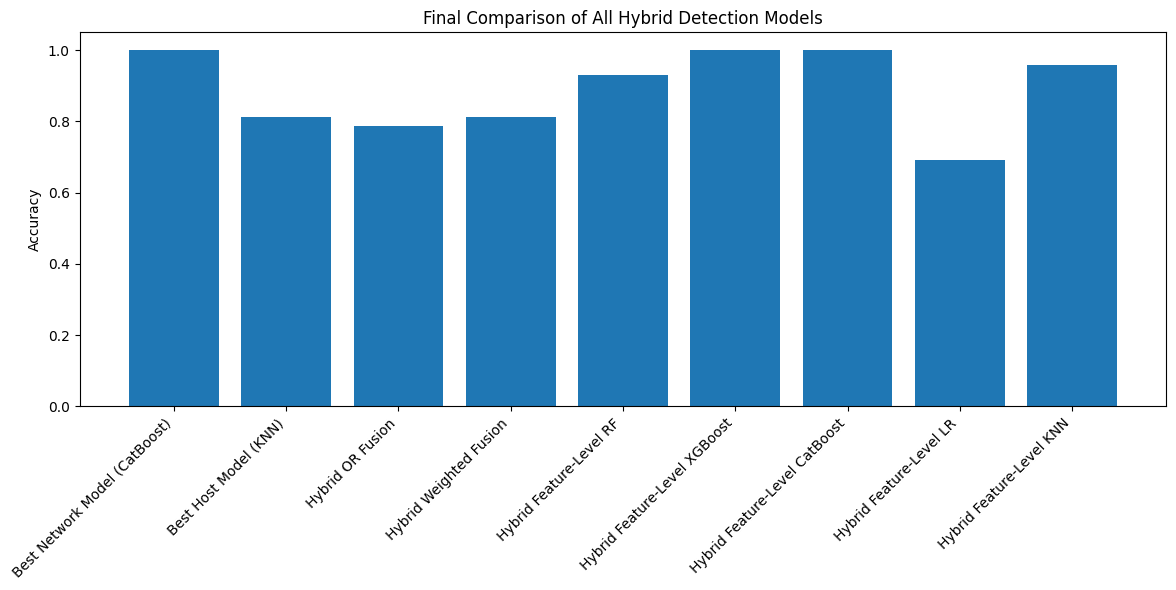

In [73]:
# Cell 47: Plot Final Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(final_results_summary["Model"], final_results_summary["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Final Comparison of All Hybrid Detection Models")
plt.tight_layout()
plt.show()

OR Fusion

Test set distribution:
y_true_host
0    1582
1    1581
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.71      0.77      1582
   Malicious       0.75      0.87      0.80      1581

    accuracy                           0.79      3163
   macro avg       0.80      0.79      0.79      3163
weighted avg       0.80      0.79      0.79      3163



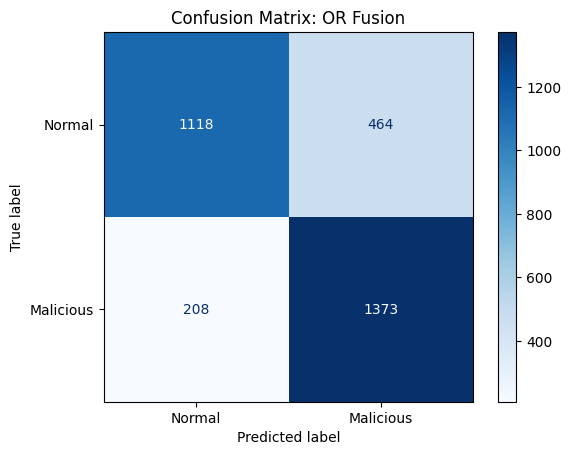

Weighted Fusion

Test set distribution:
y_true_host
0    1582
1    1581
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.78      0.81      1582
   Malicious       0.79      0.85      0.82      1581

    accuracy                           0.81      3163
   macro avg       0.81      0.81      0.81      3163
weighted avg       0.81      0.81      0.81      3163



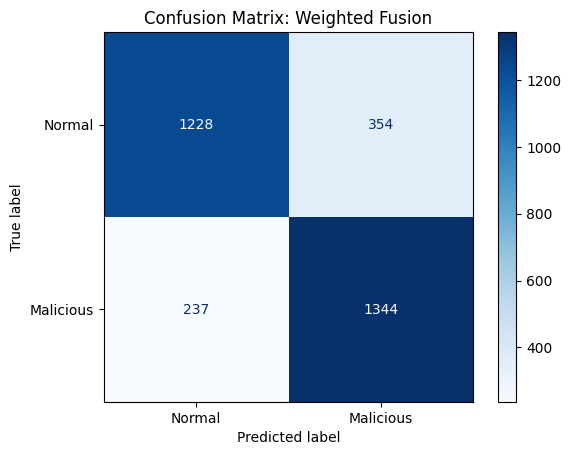

Feature-Level RF

Test set distribution:
label
0    2888
1     275
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.92      0.96      2888
   Malicious       0.55      1.00      0.71       275

    accuracy                           0.93      3163
   macro avg       0.77      0.96      0.83      3163
weighted avg       0.96      0.93      0.94      3163



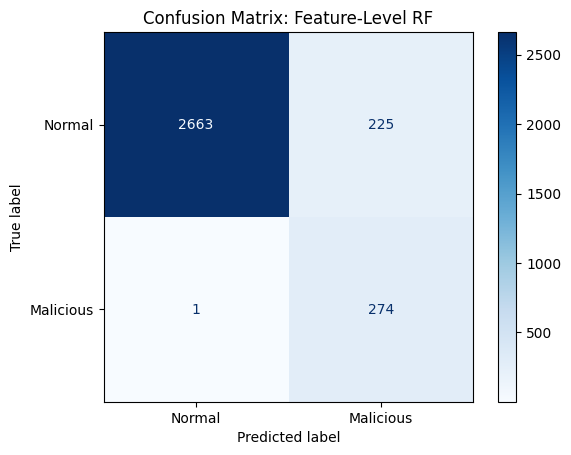

Feature-Level XGBoost

Test set distribution:
label
0    2888
1     275
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2888
   Malicious       1.00      1.00      1.00       275

    accuracy                           1.00      3163
   macro avg       1.00      1.00      1.00      3163
weighted avg       1.00      1.00      1.00      3163



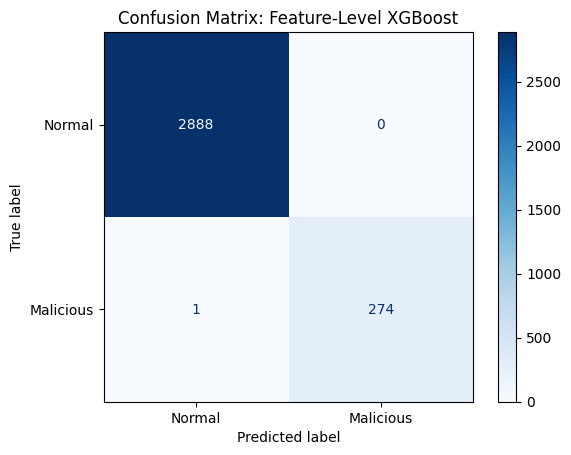

Feature-Level CatBoost

Test set distribution:
label
0    2888
1     275
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2888
   Malicious       1.00      1.00      1.00       275

    accuracy                           1.00      3163
   macro avg       1.00      1.00      1.00      3163
weighted avg       1.00      1.00      1.00      3163



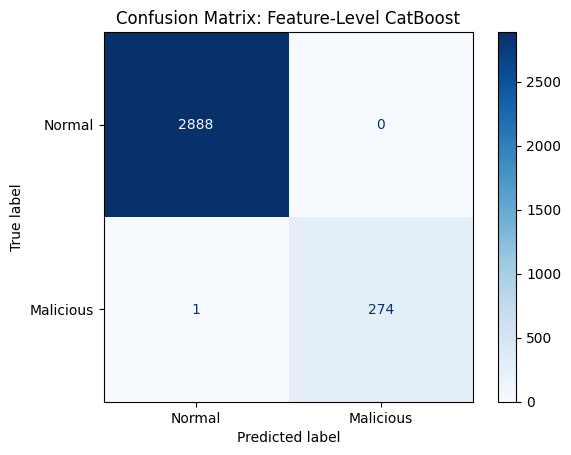

Feature-Level KNN

Test set distribution:
label
0    2888
1     275
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      2888
   Malicious       0.80      0.69      0.74       275

    accuracy                           0.96      3163
   macro avg       0.89      0.84      0.86      3163
weighted avg       0.96      0.96      0.96      3163



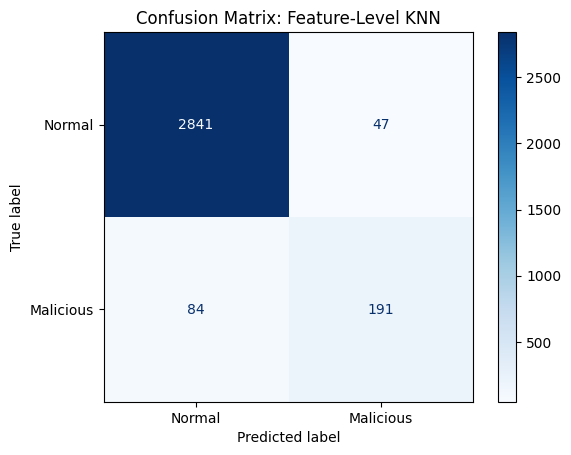

Feature-Level Logistic Regression

Test set distribution:
label
0    2888
1     275
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.66      0.80      2888
   Malicious       0.22      0.99      0.36       275

    accuracy                           0.69      3163
   macro avg       0.61      0.83      0.58      3163
weighted avg       0.93      0.69      0.76      3163



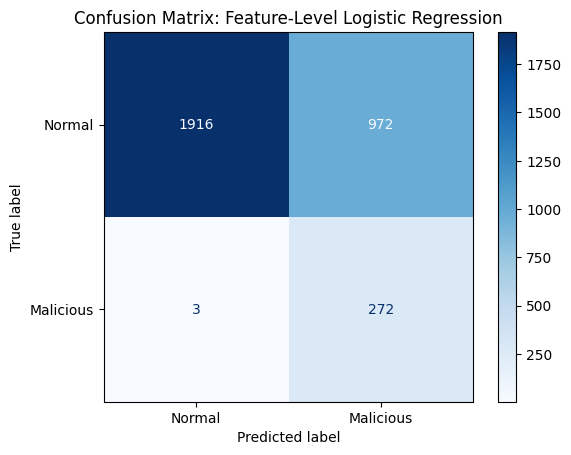

In [74]:
#CE Hybrid Confusion Matrices

from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

hybrid_models = {
    "OR Fusion": (hybrid_true, hybrid_pred_or),
    "Weighted Fusion": (hybrid_true, hybrid_pred_weighted),
    "Feature-Level RF": (y_test_fusion, rf_fusion_pred),
    "Feature-Level XGBoost": (y_test_fusion, xgb_fusion_pred),
    "Feature-Level CatBoost": (y_test_fusion, cat_fusion_pred),
    "Feature-Level KNN": (y_test_fusion, knn_fusion_pred),
    "Feature-Level Logistic Regression": (y_test_fusion, lr_fusion_pred)
}

for model_name, (y_true, y_pred) in hybrid_models.items():
    print("=" * 60)
    print(model_name)

    print("\nTest set distribution:")
    print(pd.Series(y_true).value_counts().sort_index())

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Malicious"]
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["Normal", "Malicious"],
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()